In [1]:
# Import packages
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

In [2]:
# Load cleaned data
corn = pd.read_csv('../data/processed-data/corn_acreage_cleaned.csv', dtype={'FIPS': str})
 
# Ensure FIPS is always 5 characters (zero-padded)
corn['FIPS'] = corn['FIPS'].str.zfill(5)
 
print(f"Corn data loaded: {len(corn)} counties")

Corn data loaded: 1573 counties


In [3]:
# Download county shapefiles
print("Loading county shapefile...")
county_shp = gpd.read_file('../data/raw-data/tl_2012_us_county.zip')
print(f"Shapefile loaded: {len(county_shp)} counties")

Loading county shapefile...
Shapefile loaded: 3234 counties


In [4]:
# Prepare shapefiles for merging
county_shp['FIPS'] = county_shp['STATEFP'] + county_shp['COUNTYFP']
 
# Drop non-contiguous states and territories for a cleaner map
exclude = ['02', '15', '60', '66', '69', '72', '78']
county_shp = county_shp[~county_shp['STATEFP'].isin(exclude)]

# Focus on corn belt
# corn_belt = [
#     '17', '18', '19', '20', '27', '29', '31',  # IL, IN, IA, KS, MN, MO, NE
#     '38', '39', '46', '55'                       # ND, OH, SD, WI
# ]
# county_shp = county_shp[county_shp['STATEFP'].isin(corn_belt)]

# Merge shapefile with corn data
merged = county_shp.merge(corn, on='FIPS', how='left')
print(f"Counties with corn data after merge: {merged['change_acres'].notna().sum()}")

Counties with corn data after merge: 1573



Map saved to corn_acreage_change_map.png


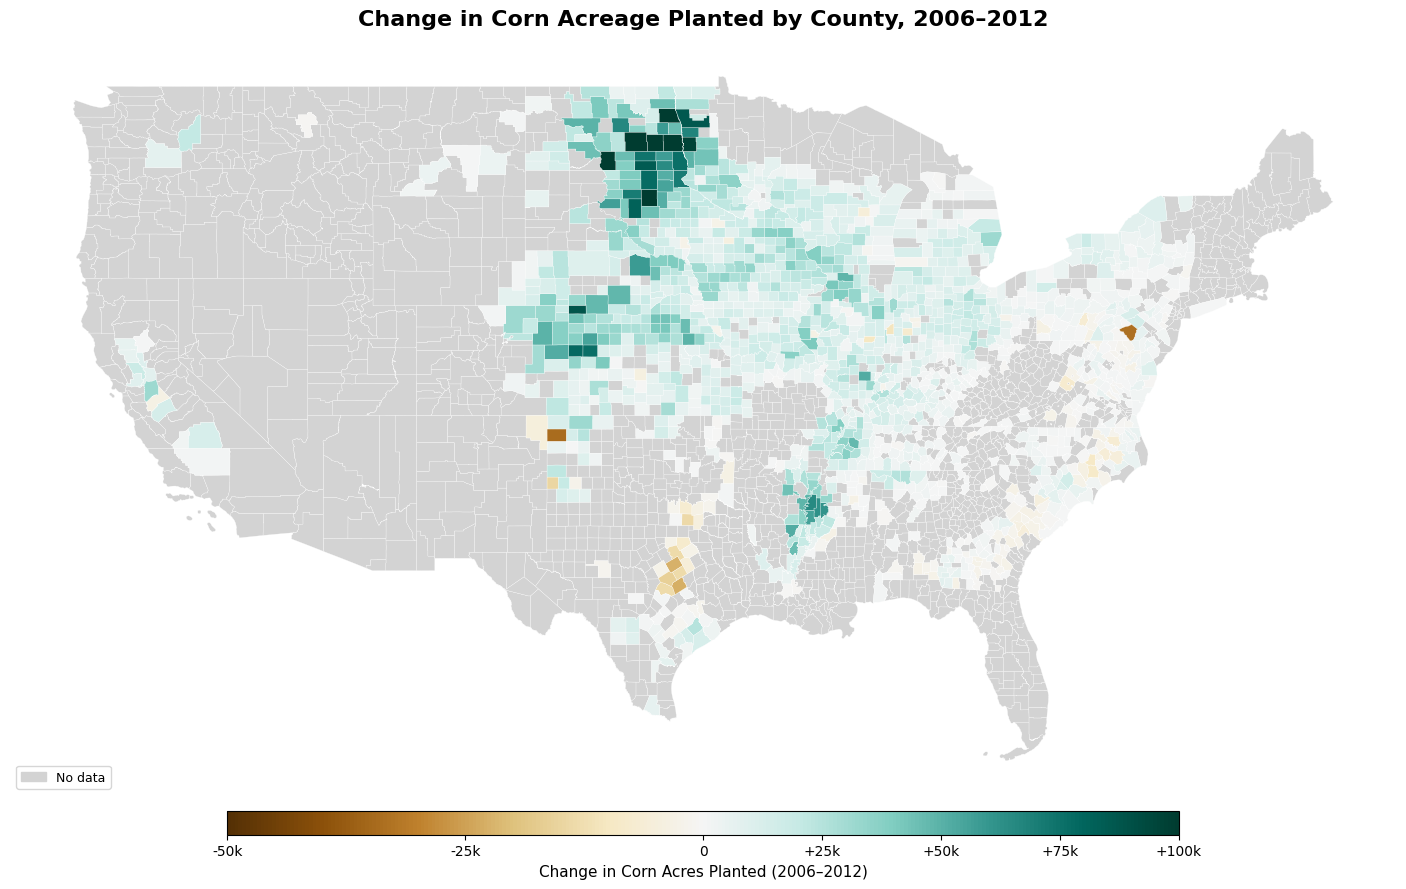

In [5]:
# Color map
cmap = plt.cm.BrBG      # Brown-Blue-Green diverging colormap
vmin = -50_000
vmax = 100_000
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(16, 9))
 
# Plot counties with no data (grey background layer first)
merged[merged['change_acres'].isna()].plot(
    ax=ax,
    color='#d3d3d3',
    edgecolor='white',
    linewidth=0.2
)
 
# Plot counties with data, colored by change in acres
merged[merged['change_acres'].notna()].plot(
    ax=ax,
    column='change_acres',
    cmap=cmap,
    norm=norm,
    edgecolor='white',
    linewidth=0.2,
    legend=False
)

# Add color bar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal',
                    fraction=0.03, pad=0.02, aspect=40)
cbar.set_label('Change in Corn Acres Planted (2006–2012)', fontsize=11)
cbar.set_ticks([-50_000, -25_000, 0, 25_000, 50_000, 75_000, 100_000])
cbar.set_ticklabels(['-50k', '-25k', '0', '+25k', '+50k', '+75k', '+100k'])

# Add legend patch for counties with missing data
no_data_patch = mpatches.Patch(color='#d3d3d3', label='No data')
ax.legend(handles=[no_data_patch], loc='lower left', fontsize=9)

# Titles and cleanup 
ax.set_title(
    'Change in Corn Acreage Planted by County, 2006–2012',
    fontsize=16, fontweight='bold', pad=12
)
ax.set_xlabel(
    'Green = increase  |  Brown = decrease  |  Color scale capped at ±150k acres',
    fontsize=9, color='grey'
)
ax.axis('off')
 
plt.tight_layout()
plt.savefig('../outputs/corn_acreage_change_map.png', dpi=150, bbox_inches='tight')
print("\nMap saved to corn_acreage_change_map.png")
plt.show()